In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
from labmate.acquisition_notebook import AcquisitionAnalysisManager

In [3]:
from utils.plot_style import set_plot_style 
set_plot_style()

In [9]:
path_folder_data = r"./data/oscilloscope/scope_acq_2026_05_12__07_45_12/"
folder_data_files = os.listdir(path_folder_data)
print(folder_data_files)

['oscilloscope_trace', 'temp.json']


In [10]:
# fine data scan :
name_exp = 'oscilloscope_trace'
name = "2026_05_12__08_05_23__oscilloscope_trace.h5"
full_path = os.path.join(path_folder_data, name_exp, name)
aqm = AcquisitionAnalysisManager( os.path.join(path_folder_data, name_exp))
aqm.analysis_cell(filename=full_path)

print(aqm.data)

INFO:2026_05_12__08_05_23__oscilloscope_trace


AnalysisData (rw) (not saved): 
 {
    "CH1_pt_off" (r): "0.000e+00 (type : float64)",
    "CH1_x" (r): "shape: (125000,) (type: ndarray)",
    "CH1_xincr" (r): "8.000e-08 (type : float64)",
    "CH1_xzero" (r): "7.280e-03 (type : float64)",
    "CH1_y" (r): "shape: (125000,) (type: ndarray)",
    "CH1_y_raw" (r): "shape: (125000,) (type: ndarray)",
    "CH1_ymult" (r): "2.000e-02 (type : float64)",
    "CH1_yoff" (r): "-90.000 (type : float64)",
    "CH1_yzero" (r): "0.000e+00 (type : float64)",
    "CH2_pt_off" (r): "0.000e+00 (type : float64)",
    "CH2_x" (r): "shape: (125000,) (type: ndarray)",
    "CH2_xincr" (r): "8.000e-08 (type : float64)",
    "CH2_xzero" (r): "7.280e-03 (type : float64)",
    "CH2_y" (r): "shape: (125000,) (type: ndarray)",
    "CH2_y_raw" (r): "shape: (125000,) (type: ndarray)",
    "CH2_ymult" (r): "2.000e-02 (type : float64)",
    "CH2_yoff" (r): "-100.000 (type : float64)",
    "CH2_yzero" (r): "0.000e+00 (type : float64)",
    "CH3_pt_off" (r): "0.000e+

In [14]:
# List all files in the folder
name_exp = 'oscilloscope_trace'
folder_data_files = os.listdir(path_folder_data + '/' + name_exp)
print(folder_data_files)

['2026_05_12__07_59_52__oscilloscope_trace.h5', '2026_05_12__08_05_23__oscilloscope_trace.h5']


In [17]:
x_list = []
y_list = []
ch_list = []
file_list = []

aqm = AcquisitionAnalysisManager(os.path.join(path_folder_data, name_exp))

name = "2026_05_12__08_05_23__oscilloscope_trace.h5"
full_path = os.path.join(path_folder_data, name_exp, name)
aqm.analysis_cell(filename=full_path)

data = aqm.data

# find channels present in this file
channels = []
for ch in ["CH1", "CH2", "CH3", "CH4"]:
    if f"{ch}_x" in data and f"{ch}_y" in data:
        channels.append(ch)

for ch in channels:
    x_list.append(data[f"{ch}_x"])
    y_list.append(data[f"{ch}_y"])
    ch_list.append(ch)
    file_list.append(name)

    print(f"Loaded {name} / {ch}")

INFO:2026_05_12__08_05_23__oscilloscope_trace


Loaded 2026_05_12__08_05_23__oscilloscope_trace.h5 / CH1
Loaded 2026_05_12__08_05_23__oscilloscope_trace.h5 / CH2
Loaded 2026_05_12__08_05_23__oscilloscope_trace.h5 / CH3


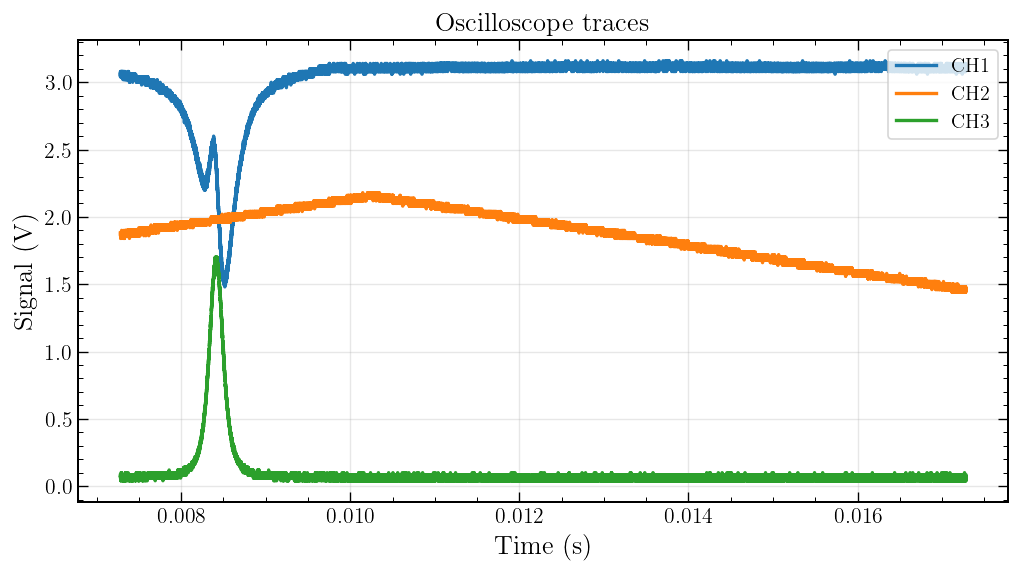

In [29]:
# Plot
plt.figure(figsize=(10,5))
for x, y, ch in zip(x_list, y_list, ch_list):
    plt.plot(x, y, label=ch)
plt.xlabel("Time (s)")
plt.ylabel(f"Signal (V)")
plt.title("Oscilloscope traces")
plt.grid()
legend = plt.legend(loc="upper right", frameon=True)
legend.get_frame().set_facecolor('white')
plt.show()